# IMPORT LIBRAIRIES

In [2]:
import os
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier


# IMPORT DATA

In [3]:
df_primary = pd.read_csv("../data/table_dataset/primary_data.csv", sep=";")
df_secondary = pd.read_csv("../data/table_dataset/secondary_data.csv", sep=";")
#df_table.info()

paths = list(Path("data/image_dataset/").rglob("*.png"))
df_image = pd.DataFrame({
    "path": paths,
    "label": [p.parent.name for p in paths]  # if folder name = class
})

# CHECK DATA 

## DF TABLE

In [3]:
print(df_primary.shape)
print(df_secondary.shape)

(173, 23)
(61069, 21)


In [4]:
df_primary.isnull().sum()

family                    0
name                      0
class                     0
cap-diameter              0
cap-shape                 0
Cap-surface              40
cap-color                 0
does-bruise-or-bleed      0
gill-attachment          28
gill-spacing             71
gill-color                0
stem-height               0
stem-width                0
stem-root               146
stem-surface            108
stem-color                0
veil-type               164
veil-color              152
has-ring                  0
ring-type                 7
Spore-print-color       155
habitat                   0
season                    0
dtype: int64

In [5]:
df_secondary.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [6]:
df_primary["class"].value_counts()

class
p    96
e    77
Name: count, dtype: int64

In [7]:
df_secondary.isna().sum()

class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64

## TRY TO MERGE ? AJOUT DU NOM AU SECONDARY DATASET


In [8]:
df_primary.head()

,family,name,class,cap-diameter,cap-shape,Cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,Spore-print-color,habitat,season
0,Amanita Family,Fly Agaric,p,"[10, 20]","[x, f]","[g, h]","[e, o]",[f],[e],NaN,...,[s],[y],[w],[u],[w],[t],"[g, p]",NaN,[d],"[u, a, w]"
1,Amanita Family,Panther Cap,p,"[5, 10]","[p, x]",[g],[n],[f],[e],NaN,...,NaN,[y],[w],[u],[w],[t],[p],NaN,[d],"[u, a]"
2,Amanita Family,False Panther Cap,p,"[10, 15]","[x, f]",NaN,"[g, n]",[f],[e],NaN,...,NaN,NaN,[w],[u],[w],[t],"[e, g]",NaN,[d],"[u, a]"
3,Amanita Family,The Blusher,e,"[5, 15]","[x, f]",NaN,[n],[t],NaN,NaN,...,[b],NaN,[w],[u],[w],[t],[g],NaN,[d],"[u, a]"
4,Amanita Family,Death Cap,p,"[5, 12]","[x, f]",[h],[r],[f],NaN,[c],...,NaN,NaN,[w],[u],[w],[t],"[g, p]",NaN,[d],"[u, a]"


In [9]:
primary_name_df = df_primary[['family','name']]
primary_name_df

,family,name
0,Amanita Family,Fly Agaric
1,Amanita Family,Panther Cap
2,Amanita Family,False Panther Cap
3,Amanita Family,The Blusher
4,Amanita Family,Death Cap
...,...,...
168,Saddle-Cup Family,White Saddle
169,Bracket Fungi,Elfin's Saddle
170,Bracket Fungi,Turban Fungus
171,Morel Family,Common Morel


In [10]:
df_primname_rep = primary_name_df.loc[primary_name_df.index.repeat(353)].reset_index(drop=True)
df_primname_rep

,family,name
0,Amanita Family,Fly Agaric
1,Amanita Family,Fly Agaric
2,Amanita Family,Fly Agaric
3,Amanita Family,Fly Agaric
4,Amanita Family,Fly Agaric
...,...,...
61064,Jelly Discs Family,Jelly Babies
61065,Jelly Discs Family,Jelly Babies
61066,Jelly Discs Family,Jelly Babies
61067,Jelly Discs Family,Jelly Babies


In [11]:
data_secondary_labelled = pd.concat([df_secondary, df_primname_rep], axis=1)
data_secondary_labelled['family'] = data_secondary_labelled['family'].str.replace(" Family", "", regex=False)
data_secondary_labelled

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,family,name
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,w,u,w,t,g,NaN,d,w,Amanita,Fly Agaric
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,w,u,w,t,g,NaN,d,u,Amanita,Fly Agaric
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,w,u,w,t,g,NaN,d,w,Amanita,Fly Agaric
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,w,u,w,t,p,NaN,d,w,Amanita,Fly Agaric
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,w,u,w,t,p,NaN,d,w,Amanita,Fly Agaric
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,p,1.18,s,s,y,f,f,f,f,3.93,...,y,NaN,NaN,f,f,NaN,d,a,Jelly Discs,Jelly Babies
61065,p,1.27,f,s,y,f,f,f,f,3.18,...,y,NaN,NaN,f,f,NaN,d,a,Jelly Discs,Jelly Babies
61066,p,1.27,s,s,y,f,f,f,f,3.86,...,y,NaN,NaN,f,f,NaN,d,u,Jelly Discs,Jelly Babies
61067,p,1.24,f,s,y,f,f,f,f,3.56,...,y,NaN,NaN,f,f,NaN,d,u,Jelly Discs,Jelly Babies


In [12]:
data_secondary_labelled.family.value_counts()

family
Tricholoma         15179
Russula             9531
Bolete              4942
Ink Cap             4589
Cortinarius         3883
Amanita             2824
Wax Gill            2824
Stropharia          2824
Entoloma            2471
Bracket Fungi       2471
Mushroom            1765
Lepiota             1059
Bolbitius           1059
Paxillus            1059
Chanterelle         1059
Pluteus              706
Oyster Mushroom      706
Crepidotus           353
Hydnum               353
Ear-Pick             353
Saddle-Cup           353
Morel                353
Jelly Discs          353
Name: count, dtype: int64

# GESTION NOMS CHAMPIGNONS

In [13]:
data_secondary_labelled['concat_mushname'] = data_secondary_labelled["family"] + " " + data_secondary_labelled["name"]
label_to_send = data_secondary_labelled['concat_mushname'].drop_duplicates()
pd.DataFrame(label_to_send)

,concat_mushname
0,Amanita Fly Agaric
353,Amanita Panther Cap
706,Amanita False Panther Cap
1059,Amanita The Blusher
1412,Amanita Death Cap
...,...
59304,Saddle-Cup White Saddle
59657,Bracket Fungi Elfin's Saddle
60010,Bracket Fungi Turban Fungus
60363,Morel Common Morel


In [14]:
df_link_name = pd.read_csv("raw_data/mushlist.csv", sep =";")
df_link_name2 = pd.read_csv("raw_data/mushlist2.csv", sep =";")
df_link_name3 = pd.read_csv("raw_data/mushlist3.csv", sep =";")

In [15]:
df_link_name['Scientific Name'].value_counts().head(15)

Scientific Name
Coprinellus micaceus        4
Tricholoma equestre         3
Tricholoma terreum          3
Tricholoma portentosum      3
Amanita citrina             2
Lepista nuda                2
Tricholoma sejunctum        2
Bolbitius titubans          2
Stropharia aeruginosa       2
Coprinopsis atramentaria    2
Coprinopsis variegata       2
Paxillus involutus          2
Cantharellus cibarius       2
Amanita muscaria            1
Amanita pantherina          1
Name: count, dtype: int64

In [16]:
df_link_name2['Scientific Name'].value_counts().head(10)

Scientific Name
Marasmius rotula      2
Hygrocybe coccinea    2
Russula claroflava    2
Amanita muscaria      1
Amanita pantherina    1
Amanita excelsa       1
Amanita rubescens     1
Amanita phalloides    1
Amanita citrina       1
Amanita virosa        1
Name: count, dtype: int64

In [17]:
df_link_name3['Scientific Name'].value_counts().head(5)

Scientific Name
Amanita muscaria      1
Amanita pantherina    1
Amanita excelsa       1
Amanita rubescens     1
Amanita phalloides    1
Name: count, dtype: int64

In [ ]:
# Chemin du dossier principal
chemin_principal1 = "data/image_dataset/edible"
chemin_principal2 = "data/image_dataset/poisonous"

# Liste des sous-dossiers
sous_dossiers1 = [f for f in os.listdir(chemin_principal1)
                 if os.path.isdir(os.path.join(chemin_principal1, f))]
sous_dossiers2 = [f for f in os.listdir(chemin_principal2)
                 if os.path.isdir(os.path.join(chemin_principal2, f))]

# Création du DataFrame
df1 = pd.DataFrame(sous_dossiers1, columns=["Scientific Name"])
df2 = pd.DataFrame(sous_dossiers2, columns=["Scientific Name"])
df_concat = pd.concat([df1, df2], ignore_index=True)
df_concat['Scientific Name'] = df_concat['Scientific Name'].str.replace("_", " ", regex=False).str.replace("-", " ", regex=False)
df_concat['image'] = "image"
df_concat.shape

(240, 2)

In [44]:
#df_link_name['tabular'] = "tabular"
#
#df_fulljoin = df_concat.merge(df_link_name, on='Scientific Name', how="outer")
#df_fulljoin = df_fulljoin.fillna("only")
#df_fulljoin['res_fulljoin'] = df_fulljoin['image'] + ' ' + df_fulljoin['tabular']
#df_fulljoin.res_fulljoin.value_counts()

In [45]:
#df_fulljoin[df_fulljoin['res_fulljoin']=="image tabular"]['Scientific Name'].value_counts()

In [19]:
df_link_name[df_link_name['Scientific Name']=="Coprinellus micaceus"]

,Common Name,Scientific Name
128,Ink Cap Glistening Ink Cap,Coprinellus micaceus
131,Ink Cap Common Crumble Cap,Coprinellus micaceus
132,Ink Cap Two-toned Crumble Cap,Coprinellus micaceus
133,Ink Cap Hay Cap,Coprinellus micaceus


In [ ]:
#df_link_name3['tabular'] = "tabular"
#
#df_fulljoin2 = df_concat.merge(df_link_name3, on='Scientific Name', how="outer")
#df_fulljoin2 = df_fulljoin2.fillna("only")
#df_fulljoin2['res_fulljoin'] = df_fulljoin2['image'] + ' ' + df_fulljoin2['tabular']
#df_fulljoin2.res_fulljoin.value_counts()

res_fulljoin
image only       193
only tabular     126
image tabular     47
Name: count, dtype: int64

In [20]:
df_link_name = df_link_name.rename(columns={"Scientific Name": "scientific_1"})
df_link_name2 = df_link_name2.rename(columns={"Scientific Name": "scientific_2"})
df_link_name3 = df_link_name3.rename(columns={"Scientific Name": "scientific_3"})

df_mushmerge = df_link_name.merge(df_link_name2, on="Common Name", how="outer")

df_mushmerge = df_mushmerge.merge(df_link_name3, on="Common Name", how="outer")
df_mushmerge

scientific_set = set(df_concat["Scientific Name"])
df_mushmerge["match_1"] = df_mushmerge["scientific_1"].isin(scientific_set)
df_mushmerge["match_2"] = df_mushmerge["scientific_2"].isin(scientific_set)
df_mushmerge["match_3"] = df_mushmerge["scientific_3"].isin(scientific_set)

In [21]:
df_mushmerge

,Common Name,scientific_1,scientific_2,scientific_3,match_1,match_2,match_3
0,Amanita Death Cap,Amanita phalloides,Amanita phalloides,Amanita phalloides,True,True,True
1,Amanita Destroying Angel,Amanita virosa,Amanita virosa,Amanita virosa,True,True,True
2,Amanita False Death Cap,Amanita citrina,Amanita citrina,Amanita citrina,True,True,True
3,Amanita False Panther Cap,Amanita citrina,Amanita excelsa,Amanita excelsa,True,False,False
4,Amanita Fly Agaric,Amanita muscaria,Amanita muscaria,Amanita muscaria,False,False,False
...,...,...,...,...,...,...,...
168,Wax Gill Meadow Wax Cap,Hygrocybe pratensis,Cuphophyllus pratensis,Cuphophyllus pratensis,False,False,False
169,Wax Gill Orange-red Wax Cap,Hygrocybe coccinea,Hygrocybe coccinea,Hygrocybe marginata,False,False,False
170,Wax Gill Parrot Wax Cap,Hygrocybe psittacina,Gliophorus psittacinus,Gliophorus psittacinus,False,False,False
171,Wax Gill Scarlet Hood,Hygrocybe punicea,Hygrocybe coccinea,Hygrocybe coccinea,False,False,False


In [31]:
df_onecorr = df_mushmerge[df_mushmerge.match_1 & ~(df_mushmerge.match_2)].sort_values(by="scientific_1")
df_onecorr

,Common Name,scientific_1,scientific_2,scientific_3,match_1,match_2,match_3
3,Amanita False Panther Cap,Amanita citrina,Amanita excelsa,Amanita excelsa,True,False,False
11,Bolete Bay Bolete,Boletus badius,Imleria badia,Imleria badia,True,False,False
162,Tricholoma Wood Woolly-foot,Clitocybe fragrans,Gymnopus peronatus,Gymnopus peronatus,True,False,False
131,Tricholoma Common Funnel Cap,Clitocybe nebularis,Infundibulicybe gibba,Infundibulicybe gibba,True,False,False
133,Tricholoma Field Blewit,Clitocybe nuda,Lepista saeva,Lepista personata,True,False,False
56,Ink Cap Common Crumble Cap,Coprinellus micaceus,Psathyrella candolleana,Psathyrella candolleana,True,False,False
62,Ink Cap Hay Cap,Coprinellus micaceus,Panaeolina foenisecii,Panaeolina foenisecii,True,False,False
67,Ink Cap Two-toned Crumble Cap,Coprinellus micaceus,Psathyrella bipellis,Psathyrella bipellis,True,False,False
58,Ink Cap Egg-shell Toadstool,Coprinopsis atramentaria,Conocybe apala,Conocybe apala,True,False,False
42,Cortinarius Red-staining Inocybe,Cortinarius rubellus,Inocybe erubescens,Inocybe erubescens,True,False,False


## check numerical data

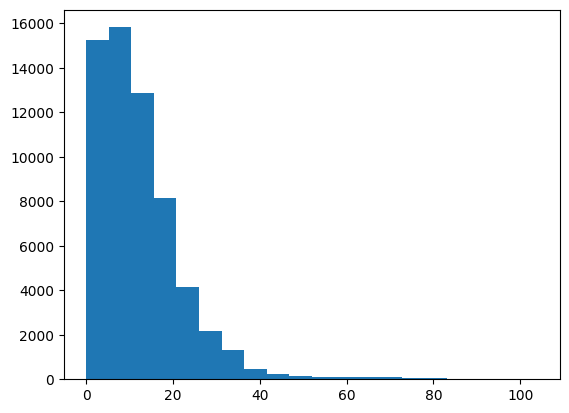

In [ ]:
#plt.hist(df_secondary['cap-diameter'], bins=20); # 0-5; 5-10; 10+
#plt.hist(df_secondary['stem-height'], bins=20); # 0-5; 5-10; 10+ / -+7
#plt.hist(df_secondary['stem-width'], bins=20); # 0-10; 10-20; 20+

## PREPARE TABULAR DATA

In [9]:
# Import data tabular
df_primary = pd.read_csv("../data/table_dataset/primary_data.csv", sep=";")
df_secondary = pd.read_csv("../data/table_dataset/secondary_data.csv", sep=";")
df_mushnames = pd.read_csv("../data/table_dataset/species_names.csv", sep =";")

# Species name from primary, add to secondary
primary_name_df = df_primary[['family','name']]
df_primname_rep = primary_name_df.loc[primary_name_df.index.repeat(353)].reset_index(drop=True)

# Clean names
data_secondary_labelled = pd.concat([df_secondary, df_primname_rep], axis=1)
data_secondary_labelled['family'] = data_secondary_labelled['family'].str.replace(" Family", "", regex=False)
#
data_secondary_labelled['Common Name'] = data_secondary_labelled["family"] + " " + data_secondary_labelled["name"]
data_secondary_labelled

# Merge to scientific names
data_merge_scname = data_secondary_labelled.merge(df_mushnames, how='left', on='Common Name')
data_tabular_final = data_merge_scname.drop(columns=['family','name','Common Name'])
data_tabular_final.columns = data_tabular_final.columns.str.replace('-', '_').str.replace(' ', '_').str.lower()
data_tabular_final["class"] = (data_tabular_final["class"] == "p").astype(int)
data_tabular_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  int64  
 1   cap_diameter          61069 non-null  float64
 2   cap_shape             61069 non-null  str    
 3   cap_surface           46949 non-null  str    
 4   cap_color             61069 non-null  str    
 5   does_bruise_or_bleed  61069 non-null  str    
 6   gill_attachment       51185 non-null  str    
 7   gill_spacing          36006 non-null  str    
 8   gill_color            61069 non-null  str    
 9   stem_height           61069 non-null  float64
 10  stem_width            61069 non-null  float64
 11  stem_root             9531 non-null   str    
 12  stem_surface          22945 non-null  str    
 13  stem_color            61069 non-null  str    
 14  veil_type             3177 non-null   str    
 15  veil_color            7413 non

In [65]:
data_tabular_final.isna().sum()
# cap_surface, gill_attachment, gill_spacing

class                       0
cap_diameter                0
cap_shape                   0
cap_surface             14120
cap_color                   0
does_bruise_or_bleed        0
gill_attachment          9884
gill_spacing            25063
gill_color                  0
stem_height                 0
stem_width                  0
stem_root               51538
stem_surface            38124
stem_color                  0
veil_type               57892
veil_color              53656
has_ring                    0
ring_type                2471
spore_print_color       54715
habitat                     0
season                      0
scientific_name             0
dtype: int64

In [66]:
# Sélection des colonnes catégorielles seulement
cat_cols = data_tabular_final.select_dtypes(include=['str']).columns

for col in cat_cols:
    print(f"--- Valeurs pour la colonne '{col}' ---")
    print(data_tabular_final[col].value_counts())
    print("\n")

--- Valeurs pour la colonne 'cap_shape' ---
cap_shape
x    26934
f    13404
s     7164
b     5694
o     3460
p     2598
c     1815
Name: count, dtype: int64


--- Valeurs pour la colonne 'cap_surface' ---
cap_surface
t    8196
s    7608
y    6341
h    4974
g    4724
d    4432
e    2584
k    2303
i    2225
w    2150
l    1412
Name: count, dtype: int64


--- Valeurs pour la colonne 'cap_color' ---
cap_color
n    24218
y     8543
w     7666
g     4420
e     4035
o     3656
r     1782
u     1709
p     1703
k     1279
b     1230
l      828
Name: count, dtype: int64


--- Valeurs pour la colonne 'does_bruise_or_bleed' ---
does_bruise_or_bleed
f    50479
t    10590
Name: count, dtype: int64


--- Valeurs pour la colonne 'gill_attachment' ---
gill_attachment
a    12698
d    10247
x     7413
p     6001
e     5648
s     5648
f     3530
Name: count, dtype: int64


--- Valeurs pour la colonne 'gill_spacing' ---
gill_spacing
c    24710
d     7766
f     3530
Name: count, dtype: int64


--- Valeurs p

In [50]:
df_primary[df_primary['stem-height']=='[0]']

,family,name,class,cap-diameter,cap-shape,Cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,Spore-print-color,habitat,season
160,Crepidotus Family,Soft Slipper Toadstool,p,"[2, 7]",[o],"[s, t]","[n, w]",[f],NaN,[c],...,[f],[f],[f],NaN,NaN,[f],[f],[n],[d],"[u, a]"
163,Bracket Fungi,Hairy Stereum,p,"[2, 6]",[o],[s],"[y, o, g, n, r]",[f],[f],[f],...,[f],[f],[f],NaN,NaN,[t],[f],NaN,[d],"[s, u, a, w]"
164,Bracket Fungi,Silver Leaf Fungus,p,"[2, 4]",[o],[l],[g],[f],[f],[f],...,[f],[f],[f],NaN,NaN,[f],[f],NaN,[d],"[s, u, a, w]"


In [53]:
# Get the scientific_name values where the other column is NaN
nan_scientific_names = data_secondary_labelled.loc[df_secondary['cap-surface'].isna(), 'name']

# If you want unique names only
nan_scientific_names_unique = nan_scientific_names.unique()
nan_scientific_names_unique

<StringArray>
[       'False Panther Cap',              'The Blusher',
          'False Death Cap',        'Amethyst Deceiver',
              'Wood Blewit',             'Field Blewit',
   'Club-footed Funnel Cap',        'Common Funnel Cap',
       'Aniseed Funnel Cap',    'Clustered Tough Shank',
      'Spotted Tough Shank',           'Stump Bell Cap',
       'Orange Moss Agaric',       'Sulphur Tricholoma',
      'Clustered Brown Cap',    'Common Yellow Russula',
    'Yellow-gilled Russula',          'Fragile Russula',
            'Birch Russula',     'Bare-toothed Russula',
       'Beechwood Sickener',      'Grass-green Russula',
         'Peppery Milk Cap',           'Sweet Milk Cap',
          'Spruce Milk Cap',            'Spring Agaric',
       'Purple Cortinarius',     'Common White Inocybe',
       'Common Crumble Cap',                  'Hay Cap',
         'Petticoat Fungus',            'Bitter Bolete',
       'Brown Birch Bolete',        'Tubed Chanterelle',
          'Oyster

## PREPROCESS OF TABULAR DATA PREPARED

In [10]:
# prepare X and y

X = data_tabular_final.drop(columns=['class','gill_spacing','stem_root','stem_surface',
                                     'veil_type','veil_color','spore_print_color','scientific_name'])
y = data_tabular_final['class']

# TTS

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3)

# pipeline num and cat
num_transformer = make_pipeline(RobustScaler())
cat_transformer = make_pipeline(SimpleImputer(strategy='constant', fill_value='u'),
                                OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))

# preprocess all
preproc_basic = make_column_transformer(
    (num_transformer, make_column_selector(dtype_include=np.number)),
    (cat_transformer, make_column_selector(dtype_exclude=np.number)),
    remainder='drop'
).set_output(transform="pandas")


# Exemple : appliquer le preprocessing sur le DataFrame
X_train_preprocessed = preproc_basic.fit_transform(X_train)
X_test_preprocessed = preproc_basic.transform(X_test)
print(X_train_preprocessed.shape)
print(X_test_preprocessed.shape)

(42748, 90)
(18321, 90)


In [69]:
42748+18321

61069

In [70]:
X_train_preprocessed.head()

,pipeline-1__cap_diameter,pipeline-1__stem_height,pipeline-1__stem_width,pipeline-2__cap_shape_b,pipeline-2__cap_shape_c,pipeline-2__cap_shape_f,pipeline-2__cap_shape_o,pipeline-2__cap_shape_p,pipeline-2__cap_shape_s,pipeline-2__cap_shape_x,...,pipeline-2__habitat_h,pipeline-2__habitat_l,pipeline-2__habitat_m,pipeline-2__habitat_p,pipeline-2__habitat_u,pipeline-2__habitat_w,pipeline-2__season_a,pipeline-2__season_s,pipeline-2__season_u,pipeline-2__season_w
48412,3.333004,4.271845,6.946303,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
48844,0.751976,0.423948,1.056338,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2200,0.461462,2.394822,0.176937,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
19937,-0.238142,0.236246,-0.258803,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15859,0.012846,-0.605178,0.177817,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [72]:
X_train_preprocessed.columns

Index(['pipeline-1__cap_diameter', 'pipeline-1__stem_height',
       'pipeline-1__stem_width', 'pipeline-2__cap_shape_b',
       'pipeline-2__cap_shape_c', 'pipeline-2__cap_shape_f',
       'pipeline-2__cap_shape_o', 'pipeline-2__cap_shape_p',
       'pipeline-2__cap_shape_s', 'pipeline-2__cap_shape_x',
       'pipeline-2__cap_surface_d', 'pipeline-2__cap_surface_e',
       'pipeline-2__cap_surface_g', 'pipeline-2__cap_surface_h',
       'pipeline-2__cap_surface_i', 'pipeline-2__cap_surface_k',
       'pipeline-2__cap_surface_l', 'pipeline-2__cap_surface_s',
       'pipeline-2__cap_surface_t', 'pipeline-2__cap_surface_u',
       'pipeline-2__cap_surface_w', 'pipeline-2__cap_surface_y',
       'pipeline-2__cap_color_b', 'pipeline-2__cap_color_e',
       'pipeline-2__cap_color_g', 'pipeline-2__cap_color_k',
       'pipeline-2__cap_color_l', 'pipeline-2__cap_color_n',
       'pipeline-2__cap_color_o', 'pipeline-2__cap_color_p',
       'pipeline-2__cap_color_r', 'pipeline-2__cap_color_u',


(array([2.3184e+04, 1.5635e+04, 2.9150e+03, 7.1900e+02, 4.7000e+01,
        0.0000e+00, 4.0000e+00, 5.6000e+01, 1.3600e+02, 5.2000e+01]),
 array([-1.08201581,  0.08557312,  1.25316206,  2.42075099,  3.58833992,
         4.75592885,  5.92351779,  7.09110672,  8.25869565,  9.42628458,
        10.59387352]),
 <BarContainer object of 10 artists>)

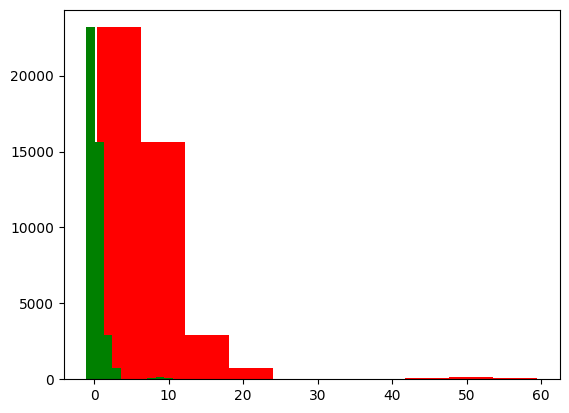

In [ ]:
plt.hist(X_train['cap_diameter'], color="r")
plt.hist(X_train_preprocessed['pipeline-1__cap_diameter'], color="g")

In [71]:
y.value_counts()

class
1    33888
0    27181
Name: count, dtype: int64

In [73]:
data_tabular_final.has_ring.value_counts()

has_ring
f    45890
t    15179
Name: count, dtype: int64

## PREPARE TABULAR DATA - Species classification


In [89]:
## Liste champignons (via noms scientifiques) dans les images

path_edible = "data/image_dataset/edible"
path_poisonous = "data/image_dataset/poisonous"

# Liste des sous-dossiers
list_edible = [f for f in os.listdir(path_edible)
                 if os.path.isdir(os.path.join(path_edible, f))]
list_poisonous = [f for f in os.listdir(path_poisonous)
                 if os.path.isdir(os.path.join(path_poisonous, f))]

# Création du DataFrame
df1 = pd.DataFrame(list_edible, columns=["scientific_name"])
df1['type'] = "edible"
df2 = pd.DataFrame(list_poisonous, columns=["scientific_name"])
df2['type'] = "poisonous"
df_concat = pd.concat([df1, df2], ignore_index=True)
df_concat['scientific_name'] = df_concat['scientific_name'].str.replace("_", " ", regex=False).str.replace("-", " ", regex=False)

# garder que le tabulaire dont l'espèce est présente dans les données d'image
data_tabular_image = data_tabular_final.merge(df_concat, how='inner', on='scientific_name')
data_tabular_image

,class,cap_diameter,cap_shape,cap_surface,cap_color,does_bruise_or_bleed,gill_attachment,gill_spacing,gill_color,stem_height,...,stem_color,veil_type,veil_color,has_ring,ring_type,spore_print_color,habitat,season,scientific_name,type
0,1,6.87,x,g,n,f,e,NaN,w,6.88,...,w,u,w,t,p,NaN,d,a,Amanita pantherina,poisonous
1,1,8.59,p,g,n,f,e,NaN,w,9.15,...,w,u,w,t,p,NaN,d,a,Amanita pantherina,poisonous
2,1,5.95,p,g,n,f,e,NaN,w,7.54,...,w,u,w,t,p,NaN,d,u,Amanita pantherina,poisonous
3,1,6.51,x,g,n,f,e,NaN,w,6.80,...,w,u,w,t,p,NaN,d,a,Amanita pantherina,poisonous
4,1,7.66,x,g,n,f,e,NaN,w,8.55,...,w,u,w,t,p,NaN,d,a,Amanita pantherina,poisonous
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16939,1,11.76,o,NaN,e,f,f,f,f,4.90,...,n,NaN,NaN,f,f,NaN,d,u,Sarcosphaera coronaria,poisonous
16940,1,8.54,o,NaN,e,f,f,f,f,3.72,...,n,NaN,NaN,f,f,NaN,d,u,Sarcosphaera coronaria,poisonous
16941,1,7.30,o,NaN,e,f,f,f,f,2.79,...,n,NaN,NaN,f,f,NaN,d,s,Sarcosphaera coronaria,poisonous
16942,1,10.40,o,NaN,n,f,f,f,f,3.82,...,n,NaN,NaN,f,f,NaN,d,u,Sarcosphaera coronaria,poisonous


In [91]:
data_tabular_image['class'].value_counts()

class
1    8825
0    8119
Name: count, dtype: int64

In [101]:
#COMPTER LE NOMBRE DIMAGES PAR POISONOUS OU EDIBLE
base_path = "data/image_dataset"

valid_images = set(data_tabular_image.scientific_name.str.replace(" ", "_", regex=False))
types = ["edible", "poisonous"]

results = []

for t in types:
    type_path = os.path.join(base_path, t)

    for folder in os.listdir(type_path):
        folder_path = os.path.join(type_path, folder)

        if os.path.isdir(folder_path) and folder in valid_images:

            # compter les fichiers images
            n_images = len([
                f for f in os.listdir(folder_path)
                if os.path.isfile(os.path.join(folder_path, f))
            ])

            results.append({
                "type": t,
                "name": folder,
                "n_images": n_images
            })
df_counts = pd.DataFrame(results)
df_counts.groupby("type")["n_images"].sum()

type
edible       888
poisonous    826
Name: n_images, dtype: int64

In [102]:
data_tabular_image.isna().sum()

class                       0
cap_diameter                0
cap_shape                   0
cap_surface              3530
cap_color                   0
does_bruise_or_bleed        0
gill_attachment          3177
gill_spacing             5295
gill_color                  0
stem_height                 0
stem_width                  0
stem_root               14120
stem_surface            10237
stem_color                  0
veil_type               15179
veil_color              14473
has_ring                    0
ring_type                 353
spore_print_color       15532
habitat                     0
season                      0
scientific_name             0
type                        0
dtype: int64

## MODELING TABULAR DATA

### XGBoost or RandomForest modeling

In [19]:
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

#model.fit(X_train_preprocessed, y_train)


In [21]:
pipe_baseline = make_pipeline(preproc_basic, model)

In [40]:
score_baseline = cross_val_score(pipe_baseline, X_train, y_train, cv=5, scoring='recall').mean()
score_baseline

np.float64(0.9992393384054227)

## MODIFY TABULAR FOR MODEL

### Enlever : cap_surface, cap_diameter, stem_height, stem_width, ring_type
### Deuxieme temps: catégoriser les 3 variables numériques

In [25]:
X2 = data_tabular_final.drop(columns=['class','gill_spacing','stem_root','stem_surface',
                                     'veil_type','veil_color','spore_print_color','scientific_name',
                                     'cap_surface','ring_type','cap_diameter','stem_height','stem_width'])
y = data_tabular_final['class']

# TTS

X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.3, random_state=3)


In [26]:
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42)

In [ ]:
#var complet : 0.999
model = XGBClassifier(objective="binary:logistic",
                      eval_metric="logloss",
                      random_state=42)
pipe_baseline = make_pipeline(preproc_basic, model)
score_baseline = cross_val_score(pipe_baseline, X_train, y_train, cv=5, scoring='precision').mean()
score_baseline

np.float64(0.9991970994172041)

In [30]:
# moins quelques vars : 0.97
model = XGBClassifier(objective="binary:logistic",
                      eval_metric="logloss",
                      random_state=42)
pipe_baseline = make_pipeline(preproc_basic, model)
score_baseline = cross_val_score(pipe_baseline, X2_train, y_train, cv=5, scoring='precision').mean()
score_baseline

np.float64(0.9702758248508886)

## REPORT CLASSIFICATION

## COMPARE : PREDICT REPORT SUR XTEST ET XTEST RANDOMIZED

In [ ]:
def add_noise_to_dataset(df, columns=None, noise_fraction=0.12, possible_values_dict=None):
    """
    Ajoute du bruit à plusieurs colonnes d'un DataFrame d'un seul coup.

    :param df: Le DataFrame de test original.
    :param columns: Liste des colonnes à bruiter. Si None, applique à toutes les colonnes.
    :param noise_fraction: La proportion de données à modifier par colonne (ex: 0.05).
    :param possible_values_dict: (Optionnel) Un dictionnaire {nom_colonne: [valeurs_possibles]}.
    :return: Un nouveau DataFrame avec le bruit ajouté.
    """
    df_noisy = df.copy()

    # Si aucune colonne n'est spécifiée, on prend toutes les colonnes du dataset
    if columns is None:
        columns = df_noisy.columns

    n_rows = len(df_noisy)
    n_noise = int(n_rows * noise_fraction)

    for col in columns:
        # 1. Déterminer les valeurs possibles pour cette colonne spécifique
        if possible_values_dict and col in possible_values_dict:
            possible_values = possible_values_dict[col]
        else:
            # Détection automatique : on prend les valeurs uniques existantes dans la colonne
            possible_values = df_noisy[col].dropna().unique()

        # Si la colonne est vide ou n'a qu'une seule valeur possible, on l'ignore
        if len(possible_values) <= 1:
            continue

        # 2. Sélectionner les lignes à modifier (indices au hasard)
        noise_indices = np.random.choice(df_noisy.index, size=n_noise, replace=False)

        # 3. Générer les nouvelles valeurs aléatoires parmi les choix possibles pour cette colonne
        random_new_values = np.random.choice(possible_values, size=n_noise)

        # 4. Appliquer le bruit
        df_noisy.loc[noise_indices, col] = random_new_values

    return df_noisy


In [41]:
X_test_noisy = add_noise_to_dataset(X_test, noise_fraction=0.10)
X2_test_noisy = add_noise_to_dataset(X2_test, noise_fraction=0.10)

In [42]:
# avec du bruit : 0.97

from sklearn.metrics import classification_report

model = XGBClassifier(objective="binary:logistic",
                      eval_metric="logloss",
                      random_state=42)
pipe_baseline = make_pipeline(preproc_basic, model)

pipe_baseline.fit(X2_train, y_train)
y_pred = pipe_baseline.predict(X2_test)
print(classification_report(y_test, y_pred))
#
y2_pred_noisy = pipe_baseline.predict(X2_test_noisy)
print(classification_report(y_test, y2_pred_noisy))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      8095
           1       0.97      0.97      0.97     10226

    accuracy                           0.97     18321
   macro avg       0.96      0.96      0.96     18321
weighted avg       0.97      0.97      0.97     18321

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      8095
           1       0.88      0.89      0.89     10226

    accuracy                           0.87     18321
   macro avg       0.87      0.87      0.87     18321
weighted avg       0.87      0.87      0.87     18321



In [44]:
from sklearn.metrics import recall_score

model = XGBClassifier(objective="binary:logistic",
                      eval_metric="logloss",
                      random_state=42)
pipe_baseline = make_pipeline(preproc_basic, model)
pipe_baseline.fit(X2_train, y_train)

noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
results = []

for noise in noise_levels:
    X2_test_noisy = X2_test.copy()
    X2_test_noisy = add_noise_to_dataset(X2_test_noisy, noise_fraction=noise)
    # Prédire avec votre modèle XGBoost déjà entraîné (xgb_model)
    y2_pred = pipe_baseline.predict(X2_test_noisy)


    # Évaluer
    acc = recall_score(y_test, y2_pred)
    results.append((noise, acc))
    print(f"Niveau de bruit : {noise*100}% -> Recall : {acc:.4f}")

Niveau de bruit : 0.0% -> Recall : 0.9699
Niveau de bruit : 5.0% -> Recall : 0.9312
Niveau de bruit : 10.0% -> Recall : 0.8883
Niveau de bruit : 15.0% -> Recall : 0.8533
Niveau de bruit : 20.0% -> Recall : 0.8173
Niveau de bruit : 30.0% -> Recall : 0.7645


In [ ]:
X_test_noisy.info()

<class 'pandas.DataFrame'>
Index: 18321 entries, 21977 to 59239
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cap_diameter          18321 non-null  float64
 1   cap_shape             18321 non-null  str    
 2   cap_surface           14447 non-null  str    
 3   cap_color             18321 non-null  str    
 4   does_bruise_or_bleed  18321 non-null  str    
 5   gill_attachment       15671 non-null  str    
 6   gill_color            18321 non-null  str    
 7   stem_height           18321 non-null  float64
 8   stem_width            18321 non-null  float64
 9   stem_color            18321 non-null  str    
 10  has_ring              18321 non-null  str    
 11  ring_type             17657 non-null  str    
 12  habitat               18321 non-null  str    
 13  season                18321 non-null  str    
dtypes: float64(3), str(11)
memory usage: 2.6 MB


In [24]:
# Sélection des colonnes catégorielles seulement
cat_cols = x_test_noisy.select_dtypes(include=['str']).columns

for col in cat_cols:
    print(f"--- Valeurs pour la colonne '{col}' ---")
    print(x_test_noisy[col].value_counts())
    print("\n")

--- Valeurs pour la colonne 'cap_shape' ---
cap_shape
x    7567
f    3877
s    2208
b    1743
o    1204
p     944
c     778
Name: count, dtype: int64


--- Valeurs pour la colonne 'cap_surface' ---
cap_surface
t    2320
s    2161
y    1837
h    1524
g    1501
d    1367
e     867
k     791
i     763
w     759
l     557
Name: count, dtype: int64


--- Valeurs pour la colonne 'cap_color' ---
cap_color
n    6568
y    2504
w    2184
g    1376
e    1277
o    1169
r     652
p     617
u     605
b     495
k     492
l     382
Name: count, dtype: int64


--- Valeurs pour la colonne 'does_bruise_or_bleed' ---
does_bruise_or_bleed
f    14525
t     3796
Name: count, dtype: int64


--- Valeurs pour la colonne 'gill_attachment' ---
gill_attachment
a    3725
d    3016
x    2298
p    1931
s    1762
e    1716
f    1223
Name: count, dtype: int64


--- Valeurs pour la colonne 'gill_color' ---
gill_color
w    5074
y    2754
n    2719
p    1795
g    1260
f    1129
o     971
k     760
r     563
e     473
u   